**Aulas 07 - Máquinas de Vetor de Suporte - Support Vector Machines(SVM)**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/svm`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Classificação Linear da SVM

### Introdução

As SVMs se destacam em conjuntos de dados **não lineares** de pequeno a médio porte(ou seja, de centenas a milhares de instâncias), sobretudo em tarefas de classificação.

Abaixo veremos um exemplo com o ***Conjunto de Dados da Flor Iris***, que já utilizamos ao aprender a Regressão Logística.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [ ]:
iris.target.head(3)

,target
0,0
1,0
2,0


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

A primeira imagem, mostra as frontes de decisão da Regressão Logística, sendo que a `linha verde` tracejada nem separa as classes adequadamente. Então vamos focar em uma divisão entre duas classes, representada pelas `linhas vermelha e magenta`, que representam fronteiras de decisão que provavelmente não lidarão bem com novos dados.

Agora, observe na figura a direita, a Fronteira de Decisão traçada para estas classes, utilizando o Modelo de SVM. O objetivo deste modelo, é colocar uma **"rua mais larga possível"** entre as classes.

Isso se chama **Classificação de Margem Larga**!

In [ ]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM Classifier model
svm_clf = SVC(kernel="linear", C=1e100)
svm_clf.fit(X, y)

# Bad models
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

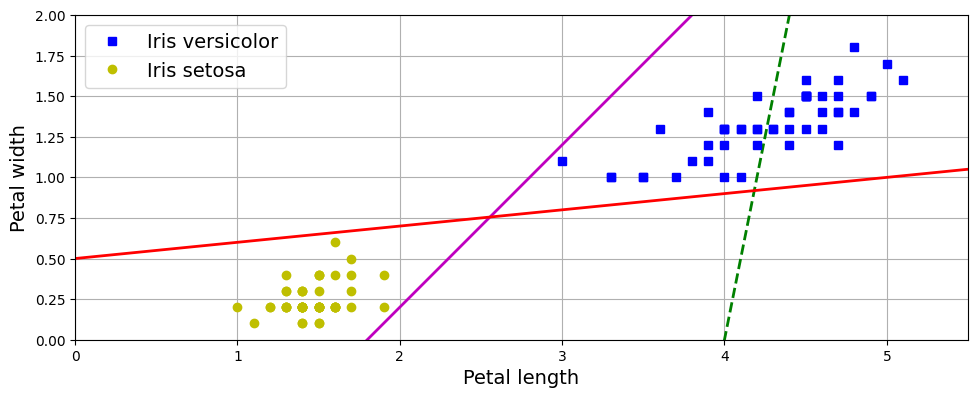

In [ ]:
fig, axes = plt.subplots(ncols=1, figsize=(10, 6), sharey=True)

plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

save_fig("large_margin_classification_plot_1")
plt.show()

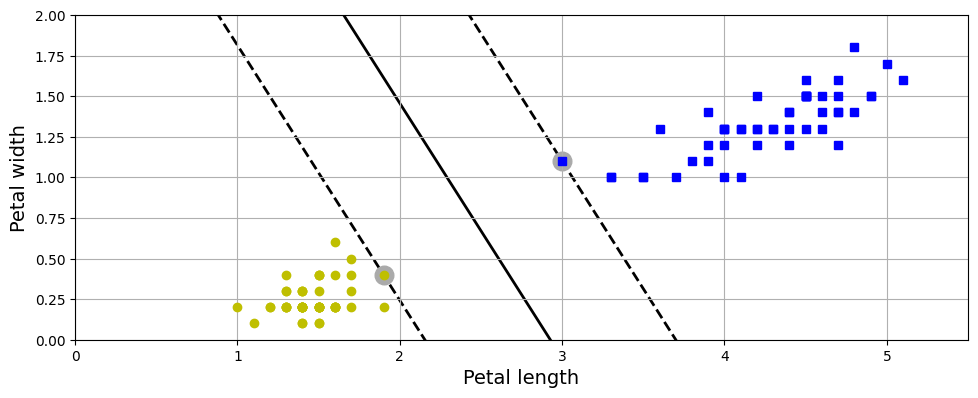

In [ ]:
fig, axes = plt.subplots(ncols=1, figsize=(10, 6), sharey=True)

plot_svc_decision_boundary(svm_clf, 0, 5.5)

plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

save_fig("large_margin_classification_plot_2")
plt.show()

**IMPORTANTE!**

O SVM é sensível ao Escolanemnto das características. Os gráficos abaixo demonstram as fronteiras de decisão traçadas após o modelo Escalonar as características utilizando o `StandardScaler` do Scikit Learn.

Observe que a Fronteira de Decisão do gráfico a direita parece ser bem melhor.

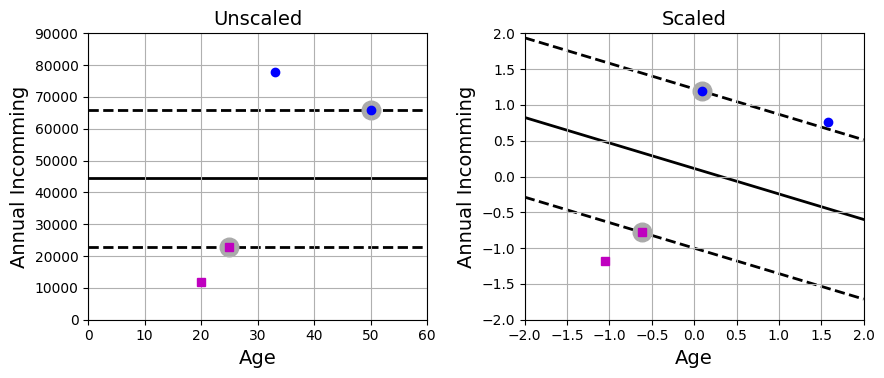

In [ ]:
from sklearn.preprocessing import StandardScaler

Xs = np.array([[20, 12000], [25, 23000], [33, 78000], [50, 66000]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100).fit(Xs, ys)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf_scaled = SVC(kernel="linear", C=100).fit(X_scaled, ys)

plt.figure(figsize=(9, 4))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 60)
plt.xlabel("Age")
plt.ylabel("Annual Incomming")
plt.title("Unscaled")
plt.axis([0, 60, 0, 90000])
plt.grid()

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf_scaled, -2, 2)
plt.xlabel("Age")
plt.ylabel("Annual Incomming")
plt.title("Scaled")
plt.axis([-2, 2, -2, 2])
plt.grid()

save_fig("sensitivity_to_feature_scales_plot")
plt.show()

## Classificação de Margem Suave

Ao definir que todas as instâncias devem ficar de fora da rua e na margem correta, corremos o risco de não conseguir lidar com valores atípicos.

É necessário encontrar uma um bom equilíbrio entre manter a rua o maior possível e limitar violações de margem.

Isso é a **Classificação de Margem Suave**.

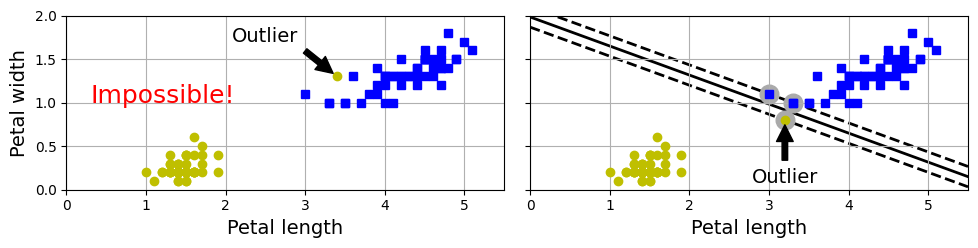

In [ ]:
X_outliers = np.array([[3.4, 1.3], [3.2, 0.8]])
y_outliers = np.array([0, 0])
Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)
yo1 = np.concatenate([y, y_outliers[:1]], axis=0)
Xo2 = np.concatenate([X, X_outliers[1:]], axis=0)
yo2 = np.concatenate([y, y_outliers[1:]], axis=0)

svm_clf2 = SVC(kernel="linear", C=10**9)
svm_clf2.fit(Xo2, yo2)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(Xo1[:, 0][yo1==1], Xo1[:, 1][yo1==1], "bs")
plt.plot(Xo1[:, 0][yo1==0], Xo1[:, 1][yo1==0], "yo")
plt.text(0.3, 1.0, "Impossible!", color="red", fontsize=18)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.annotate(
    "Outlier",
    xy=(X_outliers[0][0], X_outliers[0][1]),
    xytext=(2.5, 1.7),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

plt.sca(axes[1])
plt.plot(Xo2[:, 0][yo2==1], Xo2[:, 1][yo2==1], "bs")
plt.plot(Xo2[:, 0][yo2==0], Xo2[:, 1][yo2==0], "yo")
plot_svc_decision_boundary(svm_clf2, 0, 5.5)
plt.xlabel("Petal length")
plt.annotate(
    "Outlier",
    xy=(X_outliers[1][0], X_outliers[1][1]),
    xytext=(3.2, 0.08),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
)
plt.axis([0, 5.5, 0, 2])
plt.grid()

save_fig("sensitivity_to_outliers_plot")
plt.show()

**Nota**: o valor padrão do hiperparâmetro `dual` dos estimadores `LinearSVC` e `LinearSVR` mudará de `True` para `"auto"` no Scikit-Learn 1.4, então usaremos `dual=True` ao longo deste notebook para garantir que a saída permaneça inalterada.


Agora vamos treinar um Modelo utilizando o classificador LinearSVC da Scikit Learn, que vai nos permitir treinar um Classificador para detectar as flores *Iris Virginica*.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=1, dual=True, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, dual=True, random_state=42))])

Agora utilizaremos o modelo treinado para fazer Predições, enviando informações de duas plantas.

In [ ]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

A primeira foi classificada como *Iris Virginica*, já a segunda não.

As pontuações retornadas, representam a distância entre cada instância avaliada e o limite de decisão.

In [ ]:
svm_clf.decision_function(X_new)

array([ 0.66163411, -0.22036063])

**Informações importantes sobre Regularização**

Para ajustar a Margem do modelo, nos modelos de SVM do Scikit Learn, temos o hiperparametro de regularização C.

Ao diminiuir o valor para hiperparametro C, "alargamos" a margem, o que leva a mais violações da margem, e um risco maior de subajuste.

Ao aumentar o valor, a margem estreita, trazendo o risco de sobreajuste o modelo.

No exemplo abaixo, o modelo claramente se adaptou melhor com o valor 100 para o hiperparametro C.

/tmp/ipykernel_12950/2104881050.py:23: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  support_vectors_idx1 = (t * (X.dot(w1) + b1) < 1).ravel()
/tmp/ipykernel_12950/2104881050.py:24: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  support_vectors_idx2 = (t * (X.dot(w2) + b2) < 1).ravel()


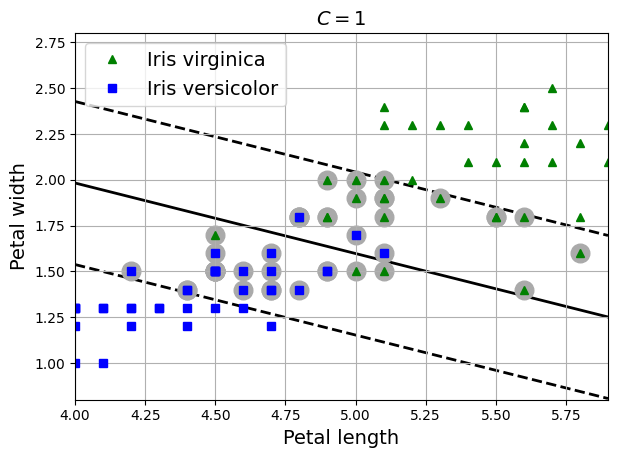

In [ ]:
scaler = StandardScaler()
svm_clf1 = LinearSVC(C=1, max_iter=10_000, dual=True, random_state=42)
svm_clf2 = LinearSVC(C=100, max_iter=10_000, dual=True, random_state=42)

scaled_svm_clf1 = make_pipeline(scaler, svm_clf1)
scaled_svm_clf2 = make_pipeline(scaler, svm_clf2)

scaled_svm_clf1.fit(X, y)
scaled_svm_clf2.fit(X, y)

# Convert to unscaled parameters
b1 = svm_clf1.decision_function([-scaler.mean_ / scaler.scale_])
b2 = svm_clf2.decision_function([-scaler.mean_ / scaler.scale_])
w1 = svm_clf1.coef_[0] / scaler.scale_
w2 = svm_clf2.coef_[0] / scaler.scale_
svm_clf1.intercept_ = np.array([b1])
svm_clf2.intercept_ = np.array([b2])
svm_clf1.coef_ = np.array([w1])
svm_clf2.coef_ = np.array([w2])

# Find support vectors (LinearSVC does not do this automatically)
t = y * 2 - 1
support_vectors_idx1 = (t * (X.dot(w1) + b1) < 1).ravel()
support_vectors_idx2 = (t * (X.dot(w2) + b2) < 1).ravel()
svm_clf1.support_vectors_ = X[support_vectors_idx1]
svm_clf2.support_vectors_ = X[support_vectors_idx2]

plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Iris virginica")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Iris versicolor")
plot_svc_decision_boundary(svm_clf1, 4, 5.9)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.title(f"$C = {svm_clf1.C}$")
plt.axis([4, 5.9, 0.8, 2.8])
plt.grid()

save_fig("regularization_plot_c1")
plt.show()

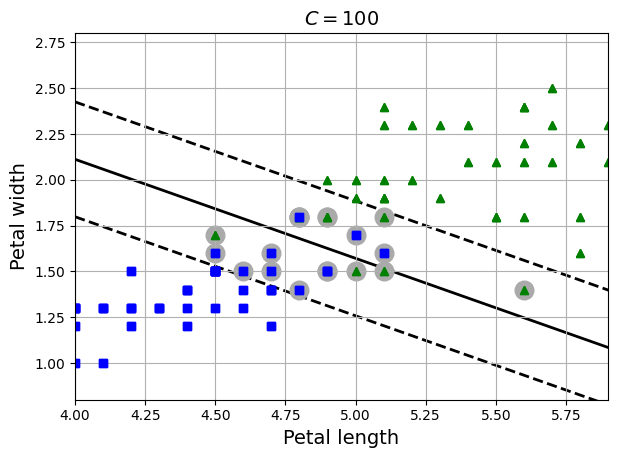

In [ ]:
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Iris virginica")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plot_svc_decision_boundary(svm_clf2, 4, 5.99)
plt.ylabel("Petal width")
plt.xlabel("Petal length")
plt.title(f"$C = {svm_clf2.C}$")
plt.axis([4, 5.9, 0.8, 2.8])
plt.grid()

save_fig("regularization_plot_c100")
plt.show()

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

# Classificação SVM Não Linear

Há casos em que os dados não pode ser separados de forma linear. Uma abordagem para abordar este problema, é adicionar mais características. Um bom exemplo, é adicionar uma característica polinomial ao conjunto de dados, e em muitos casos, isso pode gerar um conjunto de dados linearmente separável.

Abaixo temos um exemplo em que temos um conjunto de dados não linear, que após receber uma característica polinomial, se torna liearmente separável.

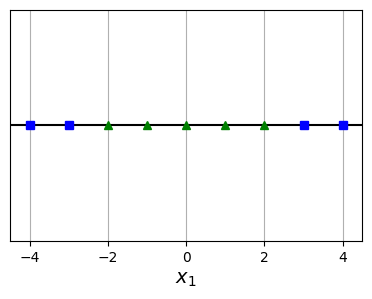

In [ ]:
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel("$x_1$")
plt.axis([-4.5, 4.5, -0.2, 0.2])

save_fig("higher_dimensions_plot_1d", tight_layout=False)
plt.show()

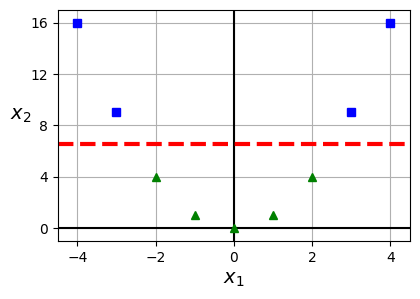

In [ ]:
plt.figure(figsize=(10, 3))

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$  ", rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

save_fig("higher_dimensions_plot_2d", tight_layout=False)
plt.show()

Agora, temos um teste utilizando o conjunto de dados "moons", um conjunto de dados de testes, para classificação binária. Você pode gerar este dataset com a função `make_moons`.

Neste exemplo, será montado um `pipeline` aplicando os transformadores `PolynomialFeatures`, `StandardScaler`, seguindo pelo classificador `LinearSVC`, que vai treinar o modelo.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, dual=True, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, dual=True, max_iter=10000, random_state=42))])

Abaixo, temos a representação gráfica do conjunto de dados, e as devidas áreas de classificação, após o treinamento do modelo utilizando as informações geradas pelos transformadores.

Observe que os pontos dos dados ficaram delimitados por dois semicirculos intercalados.

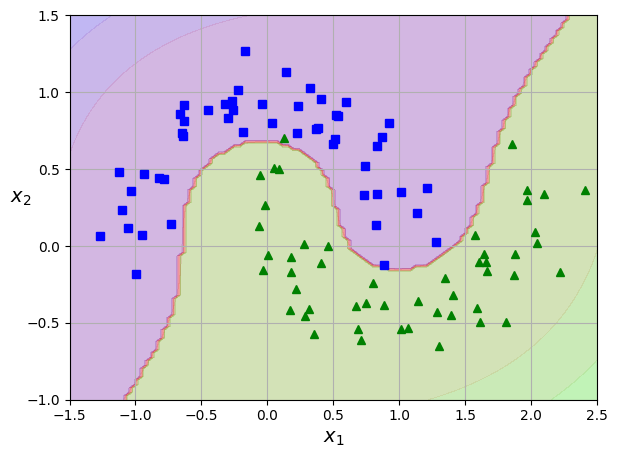

In [ ]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

save_fig("moons_polynomial_svc_plot")
plt.show()

## Kernel Polinomial

**Truque de Kernel**

A ideia do Truque de Kernel, é criar uma *característica virtual* no conjunto de dados, através da aplicação de uma fórmula matemática. Isso evita a criação explícita de novas features e o custo de memória associado.

**Kernel Polinomial**

O Kernel Polinomial permite ao SVM criar fronteiras de decisão curvas ao considerar combinações polinomiais das features, sem calcular explicitamente essas novas dimensões.

In [ ]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

Abaixo temos a representação gráfica do Modelo treinado com um Kernel Polinomial de grau 3, contra um Modelo treinado com um Kernel polinomial de grau 100.

Quando maior o grau polinomial, maior o risco de sobreajuste.

O hiperparametro `coef0` controla quanto o modelo é influenciado pelo polinomios de alto grau vs baixo grau.

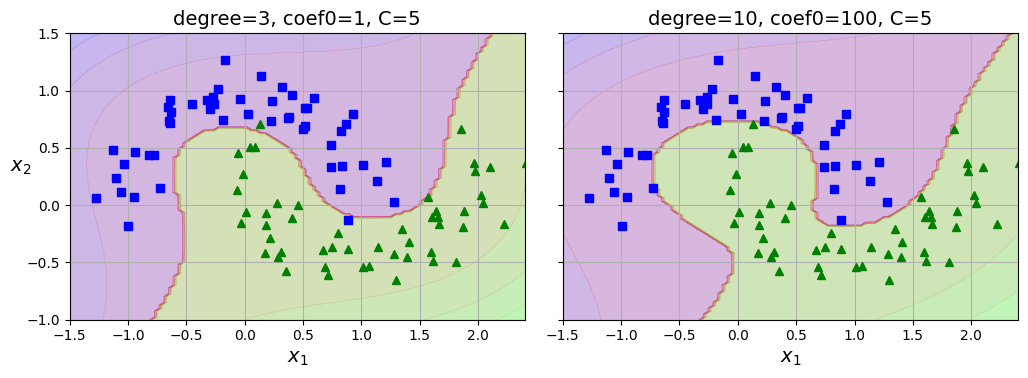

In [ ]:
poly100_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=10, coef0=100, C=5)
)
poly100_kernel_svm_clf.fit(X, y)

fig, axes = plt.subplots(ncols=2, figsize=(10.5, 4), sharey=True)

plt.sca(axes[0])
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=3, coef0=1, C=5")

plt.sca(axes[1])
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=10, coef0=100, C=5")
plt.ylabel("")

save_fig("moons_kernelized_polynomial_svc_plot")
plt.show()

## Características de Similaridade

Outra técnica para lidar com problemas não lineares, é adicionar características calculadas por uma função de similaridade.

No exemplo abaixo, temos um conjunto de dados que já vimos anteriormente, mas desta vez adicionaremos 2 pontos de referência, X2 e X3. Em seguida, será usada uma função de similaridade, com uma *função radial gaussiana*. Esta função gera um gráfico em formato de sino e varia de 0 (muito longe do ponto de referência) e 1 (no ponto de referência).

A imagem a direita, mostra os mesmos dados, mas agora em um gráfico traçado a partir dos valores calculados a partir da função de similaridade.

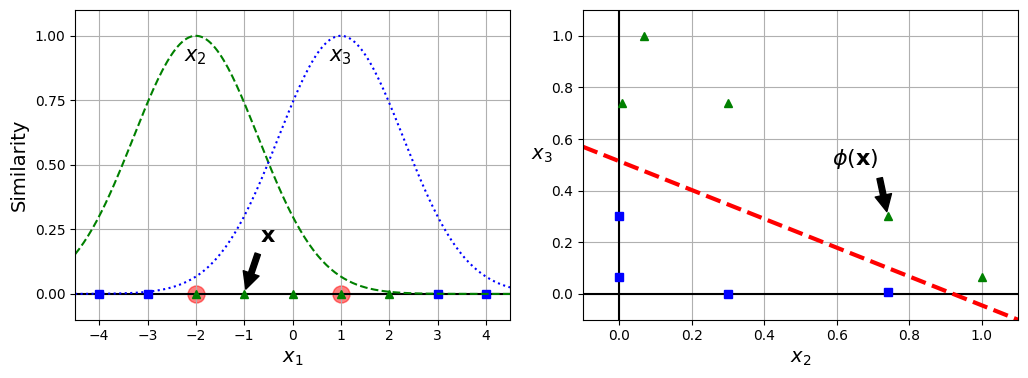

In [ ]:
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark, axis=1)**2)

gamma = 0.3

x1s = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
x2s = gaussian_rbf(x1s, -2, gamma)
x3s = gaussian_rbf(x1s, 1, gamma)

XK = np.c_[gaussian_rbf(X1D, -2, gamma), gaussian_rbf(X1D, 1, gamma)]
yk = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10.5, 4))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.scatter(x=[-2, 1], y=[0, 0], s=150, alpha=0.5, c="red")
plt.plot(X1D[:, 0][yk==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][yk==1], np.zeros(5), "g^")
plt.plot(x1s, x2s, "g--")
plt.plot(x1s, x3s, "b:")
plt.gca().get_yaxis().set_ticks([0, 0.25, 0.5, 0.75, 1])
plt.xlabel("$x_1$")
plt.ylabel("Similarity")
plt.annotate(
    r'$\mathbf{x}$',
    xy=(X1D[3, 0], 0),
    xytext=(-0.5, 0.20),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
    fontsize=16,
)
plt.text(-2, 0.9, "$x_2$", ha="center", fontsize=15)
plt.text(1, 0.9, "$x_3$", ha="center", fontsize=15)
plt.axis([-4.5, 4.5, -0.1, 1.1])

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(XK[:, 0][yk==0], XK[:, 1][yk==0], "bs")
plt.plot(XK[:, 0][yk==1], XK[:, 1][yk==1], "g^")
plt.xlabel("$x_2$")
plt.ylabel("$x_3$  ", rotation=0)
plt.annotate(
    r'$\phi\left(\mathbf{x}\right)$',
    xy=(XK[3, 0], XK[3, 1]),
    xytext=(0.65, 0.50),
    ha="center",
    arrowprops=dict(facecolor='black', shrink=0.1),
    fontsize=16,
)
plt.plot([-0.1, 1.1], [0.57, -0.1], "r--", linewidth=3)
plt.axis([-0.1, 1.1, -0.1, 1.1])

plt.subplots_adjust(right=1)

save_fig("kernel_method_plot")
plt.show()

## Kernel RBF Gaussiano

O Kernel RBF Gaussiano mede o quão “parecidos” dois pontos são com base na distância entre eles, dando mais peso aos pontos próximos e quase nenhum aos distantes. De forma muito semelhante ao exemplo apresentado acima.

Isso permite com que o modelo funcione como se você tivesse adicionado muitas características de similaridade, mas sem realmente fazer isso.

In [ ]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel="rbf", gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

O modelo representado no código acima, é apresentado no gráfico inferior à esquerda abaixo. Os demais permitem uma visualização clara, do efeito de configuração dos hiperparâmetros do modelo, conforme segue abaixo:

 - **gamma** - Controla o “zoom” do modelo, ou seja, aumentar o gamma faz com que a "curva em sino" fique mais estreita. Na prática isso diminui o intervalo de influência de cada instância, deixando a fronteira de decisão mais irregular, aumentando o risco de overfitting. Sendo assim, o gamma age como um parâmetro de regularização do modelo.

 - **C** - Controla o quanto o modelo é tolerante ao erro. Quanto maior o valor, menos o modelo tolera erros. Isso aumenta o risco de overfitting.

 Para ajustar o seu modelo, de forma geral, pode usar a regra abaixo:

| C     | gamma | Efeito                    |
| ----- | ----- | ------------------------- |
| Alto  | Alto  | Overfitting               |
| Baixo | Baixo | Underfitting              |
| Alto  | Baixo | Fronteira rígida e global |
| Baixo | Alto  | Curvas locais controladas |



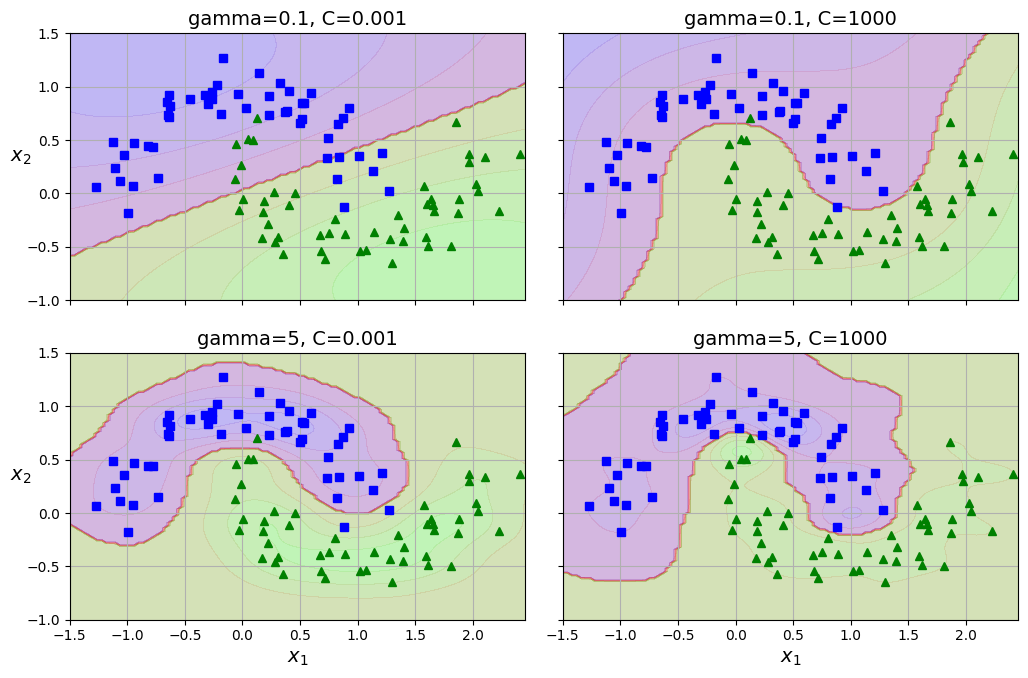

In [ ]:
from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 5
C1, C2 = 0.001, 1000
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

svm_clfs = []
for gamma, C in hyperparams:
    rbf_kernel_svm_clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma=gamma, C=C)
    )
    rbf_kernel_svm_clf.fit(X, y)
    svm_clfs.append(rbf_kernel_svm_clf)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10.5, 7), sharex=True, sharey=True)

for i, svm_clf in enumerate(svm_clfs):
    plt.sca(axes[i // 2, i % 2])
    plot_predictions(svm_clf, [-1.5, 2.45, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.45, -1, 1.5])
    gamma, C = hyperparams[i]
    plt.title(f"gamma={gamma}, C={C}")
    if i in (0, 1):
        plt.xlabel("")
    if i in (1, 3):
        plt.ylabel("")

save_fig("moons_rbf_svc_plot")
plt.show()

### LinearSVC vs SVC vs SGDClassifier e Complexidade Computacional

**`LinearSVC`**

É uma implementação otimizada para SVM linear, pensada para alto desempenho. É baseada na biblioteca `liblinear`.

*Uso indicado para*
 - Os dados são aproximadamente lineares
 - O dataset é grande
 - Performance é prioridade
 - Muitas features
 - Mais rápida e econômica em memória

*Limitações*
 - Não aceita kernel trick
 - Não fornece probabilidades diretamente
 - Menos flexível

---

**`SVC`**

A implementação clássica e completa de SVM no scikit-learn. Baseado na `libsvm` e suporta Kernel Trick.

*Uso indicado para*
 - Dados são não lineares
 - Dataset é pequeno ou médio
 - Você precisa de kernels como RBF
 - Pode precisar calcular probabilidades

*Limitações*
 - Custo computacional alto
 - Escala mal para datasets grandes
 - Uso intenso de memória (matriz de kernel)

---

**`SGDClassifier`**

É um classificador linear genérico, que pode treinar vários modelos diferentes apenas mudando a função de perda (loss). É um classificador que realiza classificação de margem grande por padrão, mas permite ajustes através de seus parâmetros de regularização.

*Uso indicado para*

- Dataset é muito grande
- Dados chegam em fluxo
- Treino precisa ser rápido
- Aceita solução aproximada

*Limitações*
- Treinamento mais instável Sensível a:
  - Taxa de aprendizado
  - Regularização
  - número de épocas
  - Resultado depende da ordem dos dados
- Requer mais cuidado no tuning.

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Regressão SVM

Para usar SVMs para regressão, em vez de classificação, o macete é inverter o objetivo. Em vez de ajustar a maior "rua" possível entre as classes, a regressão SVM tenta ajustar o maior número possível de instâncias na "rua", restringindo o número de instâncias fora da "rua". De certa forma, a ideia é criar um "tubo" por onde os dados passarão.

---

**O “tubo” ϵ (epsilon)**

Esse é o conceito mais importante da Regressão SVM. O hiperparametro ϵ (epsilon), controla o "tamanho" do tubo.

Imagine que queremos ajustar uma linha (ou curva), mas não nos importamos com erros muito pequenos.

Definimos um tubo de largura ε ao redor da função:
- Erros menores que ϵ → ignorados
- Erros maiores que ϵ → penalizados


In [ ]:
from sklearn.svm import LinearSVR

# Estas 3 linhas geram um dataset linear simples
np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(50)

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, epsilon=0.5, random_state=42))])

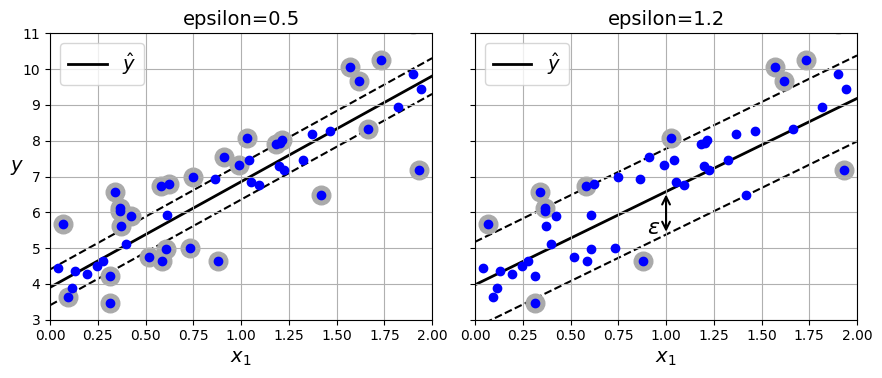

In [ ]:
def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    epsilon = svm_reg[-1].epsilon
    off_margin = np.abs(y - y_pred) >= epsilon
    return np.argwhere(off_margin)

def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    epsilon = svm_reg[-1].epsilon
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$", zorder=-2)
    plt.plot(x1s, y_pred + epsilon, "k--", zorder=-2)
    plt.plot(x1s, y_pred - epsilon, "k--", zorder=-2)
    plt.scatter(X[svm_reg._support], y[svm_reg._support], s=180,
                facecolors='#AAA', zorder=-1)
    plt.plot(X, y, "bo")
    plt.xlabel("$x_1$")
    plt.legend(loc="upper left")
    plt.axis(axes)

svm_reg2 = make_pipeline(StandardScaler(),
                         LinearSVR(epsilon=1.2, dual=True, random_state=42))
svm_reg2.fit(X, y)

svm_reg._support = find_support_vectors(svm_reg, X, y)
svm_reg2._support = find_support_vectors(svm_reg2, X, y)

eps_x1 = 1
eps_y_pred = svm_reg2.predict([[eps_x1]])

fig, axes = plt.subplots(ncols=2, figsize=(9, 4), sharey=True)
plt.sca(axes[0])
plot_svm_regression(svm_reg, X, y, [0, 2, 3, 11])
plt.title(f"epsilon={svm_reg[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.sca(axes[1])
plot_svm_regression(svm_reg2, X, y, [0, 2, 3, 11])
plt.title(f"epsilon={svm_reg2[-1].epsilon}")
plt.annotate(
        '', xy=(eps_x1, eps_y_pred), xycoords='data',
        xytext=(eps_x1, eps_y_pred - svm_reg2[-1].epsilon),
        textcoords='data', arrowprops={'arrowstyle': '<->', 'linewidth': 1.5}
    )
plt.text(0.90, 5.4, r"$\epsilon$", fontsize=16)
plt.grid()
save_fig("svm_regression_plot")
plt.show()

Também é possível utilizar a Regressão SVM para dados não lineares. A ideia é utilizar o Kernel Trick, para tratar, neste exemplo um dataset quadrático. Neste exemplo também é possível observar o efeito da regularização ao ajustar o valor do hiperparâmetro "c".

In [ ]:
from sklearn.svm import SVR

# Estas 3 lihas geram um dataset quadrático simples
np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

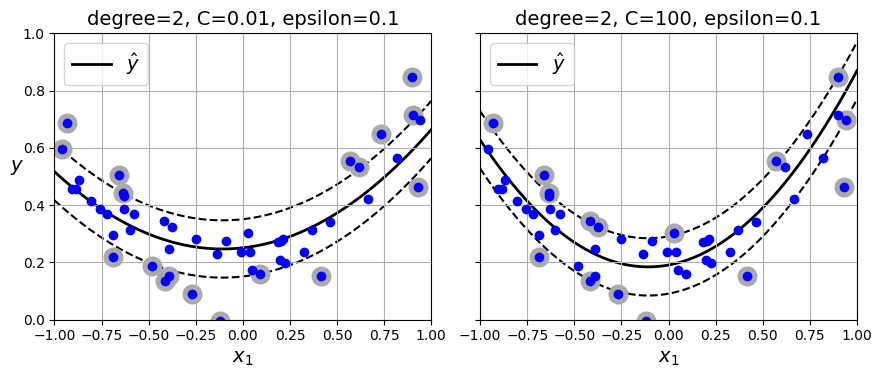

In [ ]:
svm_poly_reg2 = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=100))
svm_poly_reg2.fit(X, y)

svm_poly_reg._support = find_support_vectors(svm_poly_reg, X, y)
svm_poly_reg2._support = find_support_vectors(svm_poly_reg2, X, y)

fig, axes = plt.subplots(ncols=2, figsize=(9, 4), sharey=True)
plt.sca(axes[0])
plot_svm_regression(svm_poly_reg, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svm_poly_reg[-1].degree}, "
          f"C={svm_poly_reg[-1].C}, "
          f"epsilon={svm_poly_reg[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()

plt.sca(axes[1])
plot_svm_regression(svm_poly_reg2, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svm_poly_reg2[-1].degree}, "
          f"C={svm_poly_reg2[-1].C}, "
          f"epsilon={svm_poly_reg2[-1].epsilon}")
plt.grid()
save_fig("svm_with_polynomial_kernel_plot")
plt.show()

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

Este exercício deve ser desenvolvido utilizando o conjunto de dados que você pode carregar utilizando a função `sklearn.datasets.loadwine()`, conforme exemplo abaixo.

Este Dataset contém 174 amostras de vinho de 3 produtores diferentes

1. Prepare um novo modelo de classificação binário utilizando o Dataset Wine, com o objetivo de identificar o Produtor do Vinho, utilizando todas as características que julgar necessárias.

Calcule previsões, utilizando informações do Conjunto de Validação do Modelo.

In [ ]:
from sklearn.datasets import load_wine

wineDataset = load_wine()

print("Chaves disponíveis:", wineDataset.keys())
print("\nDescrição do dataset:\n", wineDataset.DESCR[:500], "...")

print("\nRótulos:\n", wineDataset.target_names)

Chaves disponíveis: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

Descrição do dataset:
 .. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0 ...

Rótulos:
 ['class_0' 'class_1' 'class_2']


In [ ]:
# RESOLUÇÃO EXERCÍCIO 1

2. Utilizando o Modelo que você desenvolveu, calcule as informações de Acurácia, Precisão e Recall para o modelo desenvolvido.

Considerando as métricas identificadas, e tudo o que já aprendeu, reveja o seu modelo, procurando identificar em todo o processo pontos que podem ter comprometido seu modelo de alguma forma.

Avalie se é possível melhorar o seu desempenho ajustando parâmetros ou melhorando o pré-processamento e ajuste o modelo.

É possível conseguir uma acurácia acima de 95% com este conjunto de dados.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 2

3. Utilizando como base um dos exerícios que você já desenvolveu na *Aula 4*, crie agora um modelo de regressão utilizando o SVR.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 3

4. Compare o RMSE entre os modelos calculados com cada um dos modelos. Relembre as características, recomendações, vantagens e restrições de cada modelo, para este cenário, qual você considera mais adequado para utilização?

In [ ]:
# RESOLUÇÃO EXERCÍCIO 4